In [2]:
###NN deep learning 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

data = pd.read_csv('D:/bachelor semester/datasets/nasabattery.csv')
from sklearn.model_selection import train_test_split

x = data.drop(['Current_load','Unnamed: 0','Time'], axis=1)
y = data['Time']


from sklearn.preprocessing import StandardScaler

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=2)

scaler=StandardScaler()

x_train_std=scaler.fit_transform(x_train)

x_test_std=scaler.transform(x_test)

x.head()

,Voltage_measured,Current_measured,Temperature_measured,Voltage_load
0,4.246711,0.000252,6.212696,0.000
1,4.246764,-0.001411,6.234019,4.262
2,4.039277,-0.995093,6.250255,3.465
3,4.019506,-0.996731,6.302176,3.451
4,4.004763,-0.992845,6.361645,3.438


In [7]:
#evaluating functions
#R2 score & RMSE & MAER
def evaluate(y_true, y_hat, label='test'):
    mse = mean_squared_error(y_true, y_hat)
    rmse = np.sqrt(mse)
    variance = r2_score(y_true, y_hat)
    print('{} set RMSE:{}, R2:{}'.format(label, rmse, variance))


#plot real data and the predicted one to make some comparison
def plot_predActual(y_test, y_test_hat):
  
    indices = np.arange(len(y_test_hat))
    wth= 0.6
    plt.figure(figsize=(70,30))
    true_values = [int(x) for x in y_test.values]
    predicted_values = list(y_test_hat)

    plt.bar(indices, true_values, width=wth,color='b', label='True RUL')
    plt.bar([i for i in indices], predicted_values, width=0.5*wth, color='r', alpha=0.7, label='Predicted RUL')

    plt.legend(prop={'size': 40})
    plt.tick_params(labelsize=40)

    plt.show()

def plot_result(y_true, y_pred):
    plt.figure(figsize=(70, 30))
    plt.plot(y_pred, linewidth=7) 
    plt.plot(y_true, linewidth=7)  
    plt.tick_params(labelsize=40)
    plt.ylabel('RUL', fontsize=40)  # Increase font size for y-axis label
    plt.xlabel('Training Samples', fontsize=40)  # Increase font size for x-axis label
    plt.legend(('Predicted', 'True'), loc='upper right', fontsize=40)  # Increase font size for legend
    plt.show()

In [8]:
modelNN = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1) 
])

modelNN.compile(optimizer='adam', loss='mean_squared_error')

history = modelNN.fit(x_train_std, y_train, validation_split=0.1, epochs=100)


Epoch 1/100
43/43 [==============================] - 0s 3ms/step - loss: 10909144.0000 - val_loss: 11025724.0000
Epoch 2/100
43/43 [==============================] - 0s 1ms/step - loss: 10885688.0000 - val_loss: 10981028.0000
Epoch 3/100
43/43 [==============================] - 0s 1ms/step - loss: 10807703.0000 - val_loss: 10851130.0000
Epoch 4/100
43/43 [==============================] - 0s 2ms/step - loss: 10614602.0000 - val_loss: 10565714.0000
Epoch 5/100
43/43 [==============================] - 0s 1ms/step - loss: 10243007.0000 - val_loss: 10066531.0000
Epoch 6/100
43/43 [==============================] - 0s 1ms/step - loss: 9649006.0000 - val_loss: 9314561.0000
Epoch 7/100
43/43 [==============================] - 0s 2ms/step - loss: 8814932.0000 - val_loss: 8316724.5000
Epoch 8/100
43/43 [==============================] - 0s 2ms/step - loss: 7765443.5000 - val_loss: 7146287.0000
Epoch 9/100
43/43 [==============================] - 0s 1ms/step - loss: 6553828.5000 - val_loss: 5864

In [9]:
y_lr_train = modelNN.predict(x_train_std) #Prediction on train data


y_lr_test = modelNN.predict(x_test_std)  #Prediction on test data

evaluate(y_test, y_lr_test, label='test')
evaluate(y_train,y_lr_train, label='train')

21/21 [==============================] - 0s 1ms/step
test set RMSE:231.85844075772778, R2:0.9803015138271173
train set RMSE:237.51021647342967, R2:0.9802681351497423


21/21 [==============================] - 0s 2ms/step


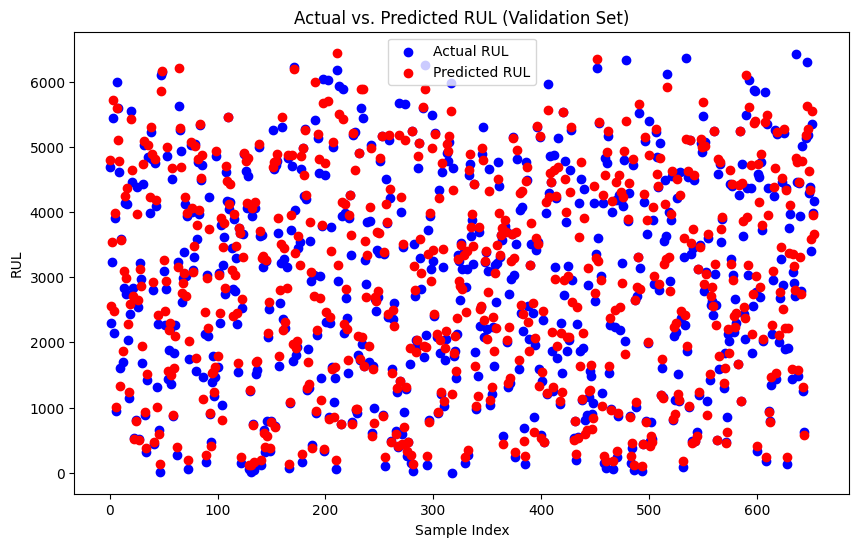

In [10]:
y_pred = modelNN.predict(x_test_std)
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='b', label='Actual RUL')
plt.scatter(range(len(y_pred)), y_pred, color='r', label='Predicted RUL')
plt.xlabel('Sample Index')
plt.ylabel('RUL')
plt.title('Actual vs. Predicted RUL (Validation Set)')
plt.legend()
plt.show()

In [11]:
modelLSTM = Sequential()
modelLSTM.add(LSTM(64, activation='relu', input_shape=(x_train_std.shape[1], 1)))
modelLSTM.add(Dense(64, activation='relu'))
modelLSTM.add(Dense(1))

modelLSTM.compile(optimizer='adam', loss='mean_squared_error')

history = modelLSTM.fit(x_train_std.reshape(-1, x_train_std.shape[1], 1), y_train, validation_data=(x_test_std.reshape(-1, x_train_std.shape[1], 1), y_test), epochs=100)

Epoch 1/100
48/48 [==============================] - 1s 6ms/step - loss: 10920584.0000 - val_loss: 11400317.0000
Epoch 2/100
48/48 [==============================] - 0s 3ms/step - loss: 9844513.0000 - val_loss: 6124970.5000
Epoch 3/100
48/48 [==============================] - 0s 3ms/step - loss: 2655120.5000 - val_loss: 1329248.1250
Epoch 4/100
48/48 [==============================] - 0s 3ms/step - loss: 1171998.2500 - val_loss: 906702.0625
Epoch 5/100
48/48 [==============================] - 0s 3ms/step - loss: 865694.4375 - val_loss: 778772.9375
Epoch 6/100
48/48 [==============================] - 0s 3ms/step - loss: 733349.8750 - val_loss: 710592.2500
Epoch 7/100
48/48 [==============================] - 0s 4ms/step - loss: 649439.6875 - val_loss: 581762.8750
Epoch 8/100
48/48 [==============================] - 0s 3ms/step - loss: 585052.3750 - val_loss: 525651.8125
Epoch 9/100
48/48 [==============================] - 0s 3ms/step - loss: 512523.3750 - val_loss: 473794.5938
Epoch 10/1

In [12]:
#bestmodelsofar
y_lr_train = modelLSTM.predict(x_train_std) #Prediction on train data


y_lr_test = modelLSTM.predict(x_test_std)  #Prediction on test data

evaluate(y_test, y_lr_test, label='test')
evaluate(y_train,y_lr_train, label='train')

21/21 [==============================] - 0s 2ms/step
test set RMSE:224.64183791186466, R2:0.9815086628365725
train set RMSE:213.69876624632687, R2:0.9840262247039112


21/21 [==============================] - 0s 1ms/step


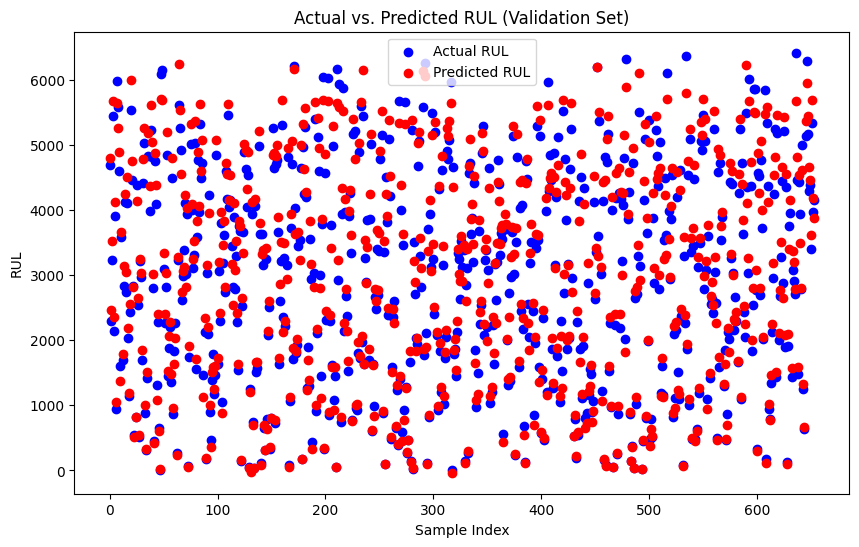

In [13]:
y_pred = modelLSTM.predict(x_test_std)
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='b', label='Actual RUL')
plt.scatter(range(len(y_pred)), y_pred, color='r', label='Predicted RUL')
plt.xlabel('Sample Index')
plt.ylabel('RUL')
plt.title('Actual vs. Predicted RUL (Validation Set)')
plt.legend()
plt.show()

In [14]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

# Reshape the data for CNN
x_train_reshaped = x_train_std.reshape(-1, x_train_std.shape[1], 1)
x_test_reshaped = x_test_std.reshape(-1, x_train_std.shape[1], 1)

modelCNN = Sequential()
modelCNN.add(Conv1D(64, 3, activation='relu', input_shape=(x_train_std.shape[1], 1)))
modelCNN.add(MaxPooling1D(2))
modelCNN.add(Flatten())
modelCNN.add(Dense(64, activation='relu'))
modelCNN.add(Dense(1))

modelCNN.compile(optimizer='adam', loss='mean_squared_error')

history = modelCNN.fit(x_train_reshaped, y_train, validation_data=(x_test_reshaped, y_test), epochs=100)


Epoch 1/100
48/48 [==============================] - 1s 4ms/step - loss: 10914805.0000 - val_loss: 11393801.0000
Epoch 2/100
48/48 [==============================] - 0s 2ms/step - loss: 10851359.0000 - val_loss: 11266934.0000
Epoch 3/100
48/48 [==============================] - 0s 2ms/step - loss: 10636086.0000 - val_loss: 10898442.0000
Epoch 4/100
48/48 [==============================] - 0s 2ms/step - loss: 10121911.0000 - val_loss: 10164025.0000
Epoch 5/100
48/48 [==============================] - 0s 2ms/step - loss: 9228838.0000 - val_loss: 8987285.0000
Epoch 6/100
48/48 [==============================] - 0s 2ms/step - loss: 7948436.5000 - val_loss: 7493897.5000
Epoch 7/100
48/48 [==============================] - 0s 3ms/step - loss: 6443092.5000 - val_loss: 5856693.0000
Epoch 8/100
48/48 [==============================] - 0s 2ms/step - loss: 4995630.5000 - val_loss: 4414634.0000
Epoch 9/100
48/48 [==============================] - 0s 2ms/step - loss: 3839776.7500 - val_loss: 33870

In [15]:
y_lr_train = modelCNN.predict(x_train_std) #Prediction on train data


y_lr_test = modelCNN.predict(x_test_std)  #Prediction on test data

evaluate(y_test, y_lr_test, label='test')
evaluate(y_train,y_lr_train, label='train')

21/21 [==============================] - 0s 968us/step
test set RMSE:547.8639184792717, R2:0.8900152609200312
train set RMSE:565.8417200020644, R2:0.8880063312777211


21/21 [==============================] - 0s 1ms/step


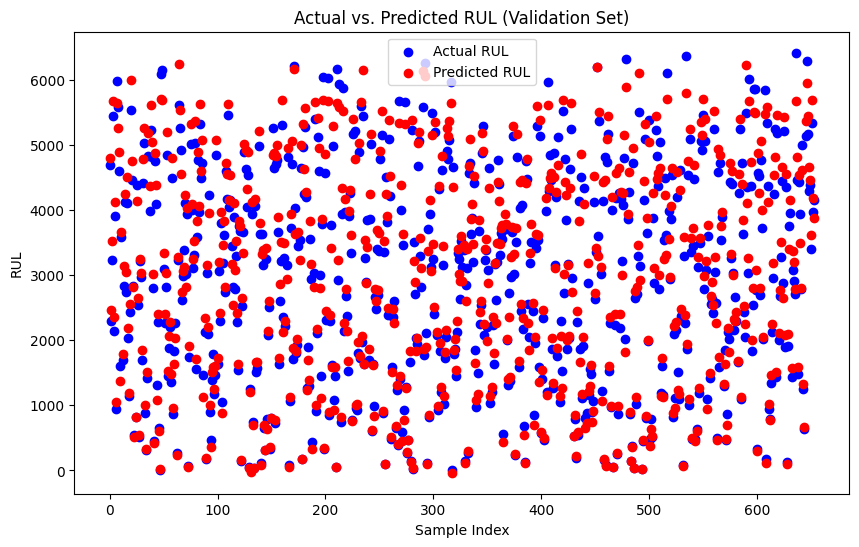

In [16]:
y_pred = modelLSTM.predict(x_test_std)
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='b', label='Actual RUL')
plt.scatter(range(len(y_pred)), y_pred, color='r', label='Predicted RUL')
plt.xlabel('Sample Index')
plt.ylabel('RUL')
plt.title('Actual vs. Predicted RUL (Validation Set)')
plt.legend()
plt.show()

In [19]:

# Input values
input_values1 = (3.817935,-0.99634,7.623793,3.249)
#497
input_values2 = (3.632405,-0.99475,7.887637,3.062)
#1563
input_values3 = (3.509587,-0.99668,8.295853,2.939)
#2759
input_values4 = (3.156657,-0.99464,10.05858,2.583)
#4996.109
input_values5 = (3.128157,-0.00154,10.80477,0)
#5650
input_values6 = (3.329356,-0.00133,8.7563813,0)
#6436
# Convert input values to a NumPy array
input_arr1 = np.asarray(input_values1)
input_arr2 = np.asarray(input_values2)
input_arr3 = np.asarray(input_values3)
input_arr4 = np.asarray(input_values4)
input_arr5 = np.asarray(input_values5)
input_arr6 = np.asarray(input_values6)

# Reshape the array to match the expected input shape of the model
input_reshaped1 = input_arr1.reshape(1, -1)  
input_reshaped2 = input_arr2.reshape(1, -1) 
input_reshaped3 = input_arr3.reshape(1, -1) 
input_reshaped4 = input_arr4.reshape(1, -1) 
input_reshaped5 = input_arr5.reshape(1, -1) 
input_reshaped6 = input_arr6.reshape(1, -1)

scaled_array1 = scaler.transform(input_reshaped1)
scaled_array2 = scaler.transform(input_reshaped2)
scaled_array3 = scaler.transform(input_reshaped3)
scaled_array4 = scaler.transform(input_reshaped4)
scaled_array5 = scaler.transform(input_reshaped5)
scaled_array6 = scaler.transform(input_reshaped6)

prediction1 = modelLSTM.predict(scaled_array1)
prediction2 = modelLSTM.predict(scaled_array2)
prediction3 = modelLSTM.predict(scaled_array3)
prediction4 = modelLSTM.predict(scaled_array4)
prediction5 = modelLSTM.predict(scaled_array5)
prediction6 = modelLSTM.predict(scaled_array6)

print(prediction1)
print(prediction2)
print(prediction3)
print(prediction4)
print(prediction5)
print(prediction6)

1/1 [==============================] - ETA: 0s

C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\python.exe\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\python.exe\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\python.exe\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\python.exe\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\python.exe\Lib\site-packages\sklearn\base.py:493: UserWa

1/1 [==============================] - 0s 16ms/step
[[531.19415]]
[[1654.779]]
[[2838.6384]]
[[5138.354]]
[[6140.077]]
[[5655.8257]]
